Git-repo: https://github.com/oggefaderen/CompSci.git
## Contributions
Lovro Antic s235263: Main contributions: Part 1 code and setup

Oskar Karlsson s244771: Main contributions: Part 2, code and setup

Uffe Grøn Roepstorff s245109: Main contributions: Part 1 and part 2 review, cleaning, reflecting, and formatting.

## Part 1: Mixing Patterns and Assortativity

### Setup: Imports and graph construction

In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict
import ast
import random
from tqdm import tqdm
import numpy as np

In [108]:
df = pd.read_csv('./D2_temp_papers.csv')
df['author_ids'] = df['author_ids'].apply(ast.literal_eval)

#Creating graph
G = nx.Graph()
pair_counts = defaultdict(int)

#Connecting the authors
for author_list in df['author_ids']:
    for i in range(len(author_list)):
        for j in range(i + 1, len(author_list)):
            pair = tuple(sorted([author_list[i].strip(), author_list[j].strip()]))
            pair_counts[pair] += 1

weighted_edgelist = [(a, b, count) for (a, b), count in pair_counts.items()]
G.add_weighted_edges_from(weighted_edgelist)
print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Graph: 466 nodes, 1202 edges


### Load country attributes

In [109]:
#We assign the known country to each person, and None if none is found
authors_df = pd.read_csv('./final_authors.csv')
country_map = dict(zip(authors_df['id'], authors_df['country_code']))

for node in G.nodes():
    G.nodes[node]['country'] = country_map.get(node, None)

countries_assigned = sum(1 for n in G.nodes() if G.nodes[n]['country'] is not None)
print(f"Country assigned to {countries_assigned}/{G.number_of_nodes()} nodes")

Country assigned to 349/466 nodes


## Q1: Country Assortativity Coefficient
*Calculate the Assortativity Coefficient for the network based on the country of each node. Implement the calculation using the formula provided during the lecture (Newman equation 2). Do not use the NetworkX implementation.*

In [110]:
# Q1: Country assortativity using Newman equation 2 (mixing matrix approach)
# r = (Tr(e) - ||e^2||) / (1 - ||e^2||)

def country_assortativity(G):
    edge_type_counts = defaultdict(int)
    total_edges = 0

    for u, v in G.edges():
        c_u = G.nodes[u].get('country')
        c_v = G.nodes[v].get('country')
        if c_u is None or c_v is None:
            continue
        # Treat as undirected: always store both orderings
        edge_type_counts[(c_u, c_v)] += 1
        edge_type_counts[(c_v, c_u)] += 1
        total_edges += 1

    countries = sorted(set(c for (c, _) in edge_type_counts))
    M = 2 * total_edges  # Denominator: counts each edge in both directions

    # e_ij fraction
    e = {(c_i, c_j): edge_type_counts.get((c_i, c_j), 0) / M
         for c_i in countries for c_j in countries}

    # Trace and marginal sums
    trace_e = sum(e[(c, c)] for c in countries)
    a = {c: sum(e[(c, c2)] for c2 in countries) for c in countries}
    sum_a_sq = sum(a[c]**2 for c in countries)

    return (trace_e - sum_a_sq) / (1 - sum_a_sq)

original_country_r = country_assortativity(G)
print(f"Country assortativity r = {original_country_r:.4f}")
print("Positive correlation: authors of the same country tend to collaborate,")
print("which is expected.")

Country assortativity r = 0.2212
Positive correlation: authors of the same country tend to collaborate,
which is expected.


## Q2: Configuration Model

Implement the configuration model using the double edge swap algorithm to generate random networks. Ensure each node retains its original degree but with altered connections.

In [111]:
def configuration_mode_swap(G):
    G_copy = G.copy()
    edges = list(G_copy.edges())
    E = len(edges)
    
    num_swaps = E * 10
    swaps_done = 0

    while swaps_done < num_swaps:
        # 1. Select two random edge indices
        idx1 = random.randrange(E)
        idx2 = random.randrange(E)
        
        if idx1 == idx2:
            continue
            
        e1 = edges[idx1]
        e2 = edges[idx2]
        u, v = e1
        x, y = e2

        # 2. Flip direction 50% of the time to remove directional bias
        if random.random() < 0.5:
            u, v = v, u

        # 3. Ensure all four nodes are distinct to prevent self-loops
        if len({u, v, x, y}) < 4:
            continue

        # 4. Swap if new edges don't already exist
        if not G_copy.has_edge(u, y) and not G_copy.has_edge(x, v):
            G_copy.remove_edge(*e1)
            G_copy.remove_edge(*e2)
            G_copy.add_edge(u, y)
            G_copy.add_edge(x, v)

            # 5. Update the edge list in-place via index
            edges[idx1] = (u, y)
            edges[idx2] = (x, v)

            swaps_done += 1

    return G_copy

### Degree sequence verification

*Verify the configuration model preserves the degree sequence.*

In [112]:
original_degrees = dict(G.degree())
G_rand = configuration_mode_swap(G)
rand_degrees = dict(G_rand.degree())

print('original_degrees == rand_degrees:',original_degrees == rand_degrees)

original_degrees == rand_degrees: True


## Q3: Country Assortativity in Random Networks

*Generate and analyze at least 100 random networks using the configuration model. For each, calculate country-based assortativity. Plot the distribution and compare with the original network to assess whether same-country connections are significantly above chance.*

Sanity check to ensure our code works
Our code:   0.2212
NX version: 0.2212


100%|██████████| 100/100 [00:03<00:00, 26.60it/s]


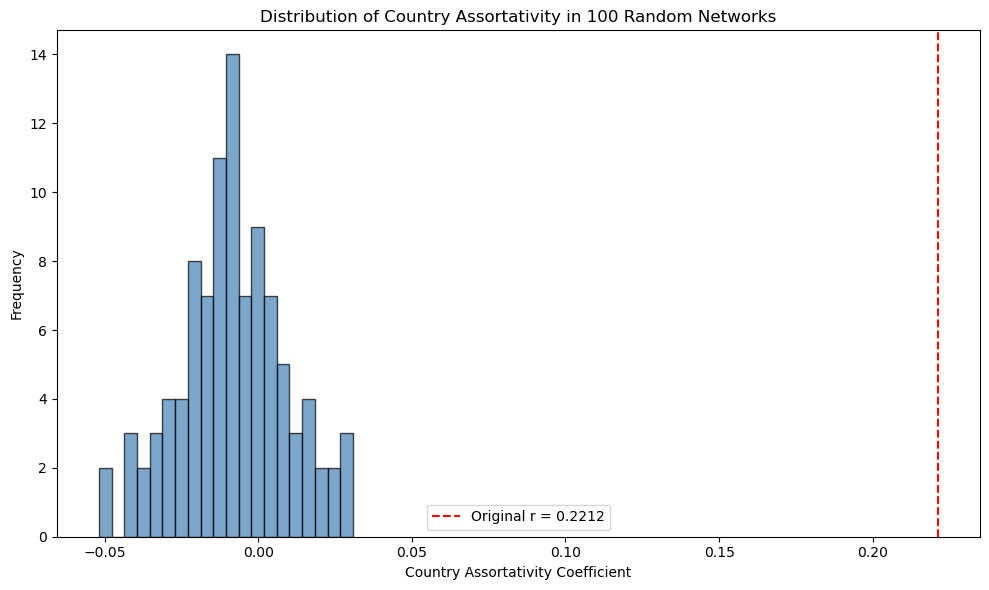

In [113]:
# Sanity check: compare our implementation with NetworkX
G_filtered = G.subgraph([n for n in G.nodes() if G.nodes[n].get('country') is not None])
print('Sanity check to ensure our code works')
print(f'Our code:   {country_assortativity(G):.4f}')
print(f'NX version: {nx.attribute_assortativity_coefficient(G_filtered, "country"):.4f}')

# Q3: Country assortativity distribution over 100 random networks
random.seed(42)
country_rs_random = []
for i in tqdm(range(100)):
    G_rand = configuration_mode_swap(G)
    for node in G_rand.nodes():
        G_rand.nodes[node]['country'] = country_map.get(node, None)
    r_rand = country_assortativity(G_rand)
    country_rs_random.append(r_rand)

plt.figure(figsize=(10, 6))
plt.hist(country_rs_random, bins=20, alpha=0.7, color='steelblue', edgecolor='black')
plt.axvline(original_country_r, color='red', linestyle='dashed',
            label=f'Original r = {original_country_r:.4f}')
plt.title('Distribution of Country Assortativity in 100 Random Networks')
plt.xlabel('Country Assortativity Coefficient')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

The assortativity values from the 100 randomized networks are centered close to 0, while the original network has a much higher country assortativity (r = 0.2212). Since the original value lies far outside the distribution, collaborations between authors from the same country are much more common than would be expected by chance under the configuration model (the plotted 100 random samples).

## Q4: Degree Assortativity

*Calculate degree assortativity for the network using the formula discussed in the lecture.*

In [114]:
# Q4: Degree assortativity using Newman's formula
def degree_assortativity(G):
    edges = list(G.edges())
    M = len(edges)
    j = np.array([G.degree(u) for u, v in edges])
    k = np.array([G.degree(v) for u, v in edges])

    # Newman eq 4: symmetric treatment of both endpoints
    mean_half_sum = (1 / (2 * M)) * np.sum(j + k)
    numerator = (1 / M) * np.sum(j * k) - mean_half_sum**2
    denominator = (1 / (2 * M)) * np.sum(j**2 + k**2) - mean_half_sum**2
    return numerator / denominator if denominator != 0 else 0

original_degree_r = degree_assortativity(G)
print(f"Degree assortativity coefficient: {original_degree_r:.4f}")

Degree assortativity coefficient: -0.1693


## Q5: Degree Assortativity in Random Networks

*Compare the network's degree assortativity against 100 random networks generated via the configuration model. Analyze whether high-degree scientists tend to connect with other high-degree scientists.*

100%|██████████| 100/100 [00:03<00:00, 25.89it/s]


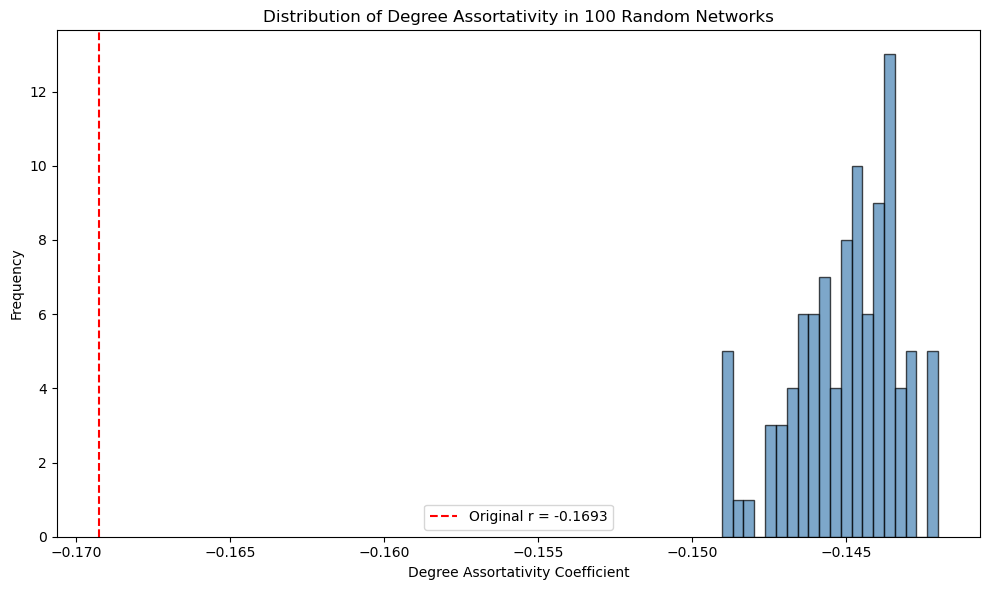

In [115]:
# Q5: Degree assortativity distribution over 100 random networks
degree_rs_random = []
for i in tqdm(range(100)):
    G_rand = configuration_mode_swap(G)
    r_rand = degree_assortativity(G_rand)
    degree_rs_random.append(r_rand)

plt.figure(figsize=(10, 6))
plt.hist(degree_rs_random, bins=20, alpha=0.7, color='steelblue', edgecolor='black')
plt.axvline(original_degree_r, color='red', linestyle='dashed',
            label=f'Original r = {original_degree_r:.4f}')
plt.title('Distribution of Degree Assortativity in 100 Random Networks')
plt.xlabel('Degree Assortativity Coefficient')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

The distribution of degree assortativity from the 100 randomized networks is tightly concentrated around approximately -0.145, with values ranging roughly from -0.150 to -0.140. The original network's degree assortativity (r = -0.1693) lies clearly to the left of this distribution, meaning the real network is more disassortative than expected by chance given its degree sequence. This suggests that high-degree scientists tend to connect with lower-degree collaborators more often than the configuration model predicts, which is consistent with hierarchical collaboration structures such as senior researchers working with students and junior coauthors.

## Q5: Reflections

#### *Assortativity by degree. Were the results of the degree assortativity in line with your expectations? Why or why not?*

The degree assortativity of our network is negative, and it sits outside the distribution produced by the 100 configuration-model randomizations. So the real network is more disassortative than what you'd get from random rewiring alone.

We initially expected some positive assortativity since scientists of similar prominence might collaborate more. But having a negative assortativity suggests that high-degree nodes (well-connected scientists) are more likely to connect with low-degree nodes (less-connected scientists). This could reflect that prominent(collaborative) scientists work with many junior researchers, (RA's, or PHD students) who have fewer connections. It's common for leaders of research labs, or supervisors to have their names on a lot of papers with many coauthors, while those coauthors might not have as many connections themselves. This could help explain the negative associativity we see in the real network.

#### *Edge flipping. In the process of implementing the configuration model, you were instructed to flip the edges (e.g., changing e_1 from (u,v) to (v,u)) 50% of the time. Why do you think this step is included?*

The flip removes a bias from how NetworkX stores edges internally. When you call `list(G.edges())`, edges come back in a fixed order based on when nodes were inserted, not randomly. Without the flip, every swap creates new edges `(u, y)` and `(x, v)` where `u` and `x` are always the "first" node from their original edge. Over E*10 swaps, this consistently favors certain nodes appearing on one side of new connections, which can skew the result.

By flipping `(u, v)` to `(v, u)` half the time, we randomize which endpoint gets paired with a new partner. This makes the swaps symmetric and unbiased over many iterations. Without it, the null distribution would partly reflect NetworkX's memory ordering rather than being a proper structural baseline.

#### *Distribution of assortativity in random networks. Describe the distribution of degree assortativity values you observed for the random networks. Was the distribution pattern expected? Discuss how the nature of random network generation (specifically, the configuration model and edge flipping) might influence this distribution and whether it aligns with theoretical expectations.*

The 100 randomized networks give degree assortativity values that cluster in a roughly bell-shaped distribution. The spread is fairly tight.

The negative center is expected. When a network has a heterogeneous degree distribution (some very high-degree nodes, many low-degree ones), random wiring tends to produce slightly disassortative networks because hubs simply can't all connect to each other when there are too few of them. The configuration model preserves this constraint by keeping the degree sequence fixed across all 100 realizations.

What stands out is that the original network falls outside the random distribution. The real collaboration network is more disassortative than what the degree sequence alone would produce. There seem to be additional hierarchical structures at play, with senior researchers acting as large hubs connecting many lower-degree collaborators like PhD students.

# Part 2 TF-IDF

In [116]:
import nltk
import ast
import string
import math
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/oskarkarlsson/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/oskarkarlsson/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [117]:
# Load community assignments
community_df = pd.read_csv('./author_communities.csv')

# Load papers with abstracts
abstracts_df = pd.read_csv('./D2_temp_papers.csv')
abstracts_df['author_ids'] = abstracts_df['author_ids'].apply(ast.literal_eval)

# Explode so each row has one author
exploded = abstracts_df.explode('author_ids')
exploded['author_ids'] = exploded['author_ids'].str.strip()

# Merge with community assignments
merged = exploded.merge(community_df, left_on='author_ids', right_on='author_id')

# Helper: convert abstract inverted index to plain text
def inverted_index_to_text(inv_idx_str):
    if pd.isna(inv_idx_str):
        return ''
    inv_idx = ast.literal_eval(inv_idx_str)
    words = [''] * (max(max(pos) for pos in inv_idx.values()) + 1)
    for word, positions in inv_idx.items():
        for pos in positions:
            words[pos] = word
    return ' '.join(words)

# Convert abstracts to text
merged['text'] = merged['abstract_inverted_index'].apply(inverted_index_to_text)

## Exercise 1

### Q1: Explain TF-IDF in your own words. What is TF? What is IDF?

**TF-IDF** (Term Frequency-Inverse Document Frequency) is a way to measure how important a word is to a specific document within a collection. It is the product of two parts.

**TF (Term Frequency)** counts how often a word appears in a document, divided by the total number of words in that document. A word that shows up a lot in one community's abstracts gets a high TF. We use raw relative frequency (count / total tokens) here, not a log-transformed version.

**IDF (Inverse Document Frequency)** downweights words that appear in many documents. It is computed as log(N / df), where N is the total number of documents and df is how many documents contain the word. We use the natural log (base e), but the choice of base is just a scaling constant and doesn't change the ranking of words within a community.

Multiplying TF by IDF gives a score that is high only when a word is both frequent locally and rare globally, which makes TF-IDF much better at picking out distinctive words than raw term frequency.

### Q2: Create Community Token Documents

For each community, create a large token document by combining all paper abstracts written by authors in that community. Use pandas `groupby` and `apply` to aggregate tokens per community.

Note: To build community documents, we exploded each paper into author-paper pairs and merged these with the community assignments. This means that papers with multiple authors from the same community contribute proportionally more text to that community’s document.

In [118]:
stop_words = set(stopwords.words('english'))

def tokenize(text):
    tokens = word_tokenize(text.lower())
    return [w for w in tokens if w not in stop_words and any(ch.isalnum() for ch in w)] # Keep tokens with at least one character or number to avoid special characters and punctuation

# Group by community — combine all tokens into one document per community
# Uses pandas groupby + apply (explode already done above)
community_docs = (
    merged.groupby('community')['text']
    .apply(lambda texts: tokenize(' '.join(texts)))
    .to_dict()
)

for comm in sorted(community_docs.keys()):
    print(f'Community {comm}: {len(community_docs[comm])} tokens')
    
print('We skip Community 12, as it\'s empy')

Community 0: 7194 tokens
Community 1: 740 tokens
Community 2: 897 tokens
Community 3: 21539 tokens
Community 4: 9603 tokens
Community 5: 950 tokens
Community 6: 25159 tokens
Community 7: 302 tokens
Community 8: 3818 tokens
Community 9: 4936 tokens
Community 10: 4519 tokens
Community 11: 2013 tokens
Community 12: 0 tokens
We skip Community 12, as it's empy


### Q3: Term Frequency Analysis

Calculate the TF (Term Frequency) for the words in the corpus of each community.

For the 5 biggest communities (by number of authors), list the top 5 terms. 

Comment on the results: do the communities share common top TF words? Why do you think this is? Do the TF values tell you something about the communities, or are the top TF words too generic?
 
 What is the log base choice for TF, and does it matter?

In [119]:
# Calculate TF for ALL communities (full corpus for IDF later)
tf_community = {}
for comm, tokens in community_docs.items():
    if len(tokens) == 0:
        tf_community[comm] = {}
        continue
    word_counts = Counter(tokens)
    total = len(tokens)
    tf_community[comm] = {word: count / total for word, count in word_counts.items()}

# Top 5 communities by author count
top5_communities = community_df['community'].value_counts().head(5).index.tolist()

print('Top 5 TF terms for the 5 largest communities (by author count):')
for comm in top5_communities:
    top_terms = sorted(tf_community[comm].items(), key=lambda x: x[1], reverse=True)[:5]
    print(f'Community {comm}: {[term for term, _ in top_terms]}')

Top 5 TF terms for the 5 largest communities (by author count):
Community 6: ['social', 'network', 'organizational', 'research', 'organizations']
Community 3: ['social', 'find', 'experiments', 'consumption', 'data']
Community 4: ['social', 'people', 'effects', 'vaccine', 'information']
Community 9: ['coverage', 'media', 'funding', 'female', 'women']
Community 0: ['political', 'social', 'text', 'data', 'model']


### Analysis

*Describe similarities and differences between the communities.*
*Why aren't the TFs not necessarily a good description of the communities?*

The top TF terms across the five largest communities overlap a lot. Words like *social*, *data*, *model*, and *network* show up near the top for multiple communities, because these are just common words in computational social science writing in general. TF rewards raw frequency, so words that are common across the whole field dominate regardless of whether they actually distinguish one community from another.

There are some community-specific terms that appear (e.g. *organizational*, *vaccine*, *coverage*), but they tend to get outranked by the generic vocabulary. So TF alone isn't great for characterizing what each community is actually about.

During the first iteration, we observed that special characters occured in the top TF terms. We fixed by only including terms with at least one letter or number.

For IDF we use the natural logarithm via `math.log` (`ln`). The choice of log base only scales all IDF values by a constant factor, so it doesn't change the ranking of words within a community.

### Q4: TF-IDF Analysis

*Calculate the TF-IDF for the words in the corpus of each community. For the 9 biggest communities (by number of authors), list the top 10 TF words and the top 10 TF-IDF words. Also list the top 3 authors (by degree) for each community.*

In [120]:
# IDF computed over ALL non-empty communities (fix: N=12, not N=5)
# N = number of communities with at least one token
N = sum(1 for c in community_docs if len(community_docs[c]) > 0)
print(f'IDF corpus size: N = {N} communities (excluding community 12 which has 0 tokens)')

idf = {}
# Collect all unique words across all non-empty communities
all_communities = [c for c in community_docs if len(community_docs[c]) > 0]
all_words = set(word for c in all_communities for word in tf_community[c])

for word in all_words:
    # df = number of communities that contain this word
    df = sum(1 for c in all_communities if word in tf_community[c])
    idf[word] = math.log(N / df)

IDF corpus size: N = 12 communities (excluding community 12 which has 0 tokens)


In [ ]:
#We have manually added the last missing names we didn't have in our authors datasets
Missing_names = {'A5063557800': 'Kiran Garimella', 
                 'A5012209374':'Oded Maler', 
                 'A5076189272': 'Lenore D. Zuck', 
                 'A5002312975': 'Joshua R. Gubler', 
                 'A5006700143': 'Eytan Bakshy'}


In [122]:
# Load supplementary author file (short IDs: 'A5109219790', not full URLs)
authors2_df = pd.read_csv('./final_authors2.csv')

# CSV1 uses full URLs as IDs; CSV2 uses bare short codes. normalise CSV2 to match
OPENALEX_BASE = 'https://openalex.org/'
name_map_csv1 = dict(zip(authors_df['id'], authors_df['display_name'])) #
name_map_csv2 = {OPENALEX_BASE + sid: name for sid, name in zip(authors2_df['author_id'], authors2_df['display_name'])}

# Manual fallback for authors absent from both CSVs (looked up by hand)
manual_names  = {OPENALEX_BASE + sid: name for sid, name in Missing_names.items()}

# Merge all three CSV1 wins on overlap; manual entries fill remaining gaps
combined_name_map = {**name_map_csv2, **manual_names, **name_map_csv1}

def author_label(author_id):
    # Return display name, or bare ID as readable fallback
    return combined_name_map.get(author_id, f"Unknown ({author_id.rsplit('/', 1)[-1]})")

# Pre-compute TF-IDF for every community (reused by the word-cloud cell)
tf_idf_community = {
    comm: {word: tf * idf.get(word, 0) for word, tf in tf_vals.items()}
    for comm, tf_vals in tf_community.items()
}

# Top-9 communities by author count
all_communities_ranked = community_df['community'].value_counts().index.tolist()
top9_communities = all_communities_ranked[:9]

still_missing = []  # collect any authors unresolved after all three sources

for comm in top9_communities:
    print(f"Community {comm}:")

    top_tf_words = sorted(tf_community[comm].items(), key=lambda x: x[1], reverse=True)[:10]
    print(f"Top 10 TF words: {[w for w, _ in top_tf_words]}")

    # Re-compute TF-IDF in-loop so the dict is up-to-date for the word-cloud cell
    tf_idf_community[comm] = {w: tf * idf.get(w, 0) for w, tf in tf_community[comm].items()}
    top_tfidf = sorted(tf_idf_community[comm].items(), key=lambda x: x[1], reverse=True)[:10]
    print(f"Top 10 TF-IDF words: {[w for w, _ in top_tfidf]}")

    top_authors = (
        community_df[community_df['community'] == comm]
        .sort_values(by=['degree', 'author_id'], ascending=[False, True])
        .head(3)
    )
    print(f"Top 3 authors: {[author_label(a) for a in top_authors['author_id']]}")

    # Flag authors still missing after all three name sources
    for aid in top_authors['author_id']:
        if aid not in combined_name_map:
            still_missing.append((comm, aid))
    print()



Community 6:
Top 10 TF words: ['social', 'network', 'organizational', 'research', 'organizations', 'information', 'performance', 'analysis', 'model', 'models']
Top 10 TF-IDF words: ['organizational', 'autistic', 'organization', 'development', 'organizations', 'hate', 'congruence', 'performance', 'coordination', 'training']
Top 3 authors: ['Kathleen M. Carley', 'Li‐Chiou Chen', 'Douglas B. Fridsma']

Community 3:
Top 10 TF words: ['social', 'find', 'experiments', 'consumption', 'data', 'content', 'also', 'youtube', 'users', 'network']
Top 10 TF-IDF words: ['consumption', 'youtube', 'content', 'prediction', 'fringe', 'predictive', 'a/b', 'explanations', 'cooperation', 'passively']
Top 3 authors: ['Duncan J. Watts', 'Jake M. Hofman', 'David Rothschild']

Community 4:
Top 10 TF words: ['social', 'people', 'effects', 'vaccine', 'information', 'experiment', 'effect', 'may', 'descriptive', 'whatsapp']
Top 10 TF-IDF words: ['whatsapp', 'descriptive', 'accept', 'norms', 'vaccine', 'intentions',

### Analysis
*Are the TF-IDF words more descriptive of the community? What is the role of IDF in making the words more descriptive?*

The TF-IDF word lists are much more useful for describing each community compared to the raw TF lists. Where TF puts generic terms like *social*, *network*, and *model* at the top of almost every community, TF-IDF pushes these common words down and brings up terms that are frequent within one community but rare across others. For example, Community 9 goes from generic terms under TF to *female*, *coverage*, and *newspapers* under TF-IDF, which clearly points to gender-and-media research. Community 4 shifts toward *whatsapp*, *norms*, and *descriptive*, suggesting behavioral-intervention research.

IDF is what makes this work. It penalizes words based on how many communities contain them. A word that appears in all 12 non-empty communities gets `log(12/12) = 0`, so its TF-IDF score becomes zero. Words that are rare across communities but frequent within one get high IDF weights, boosting their TF-IDF score. This turns a simple frequency count into a measure of how distinctive a word is, which is why TF-IDF gives a much better picture of what each community actually works on.

## Exercise 2

### Generate a word cloud for each community. Display the top 3 authors' names alongside each cloud.

Setup: imports, abstract loading, and community mapping

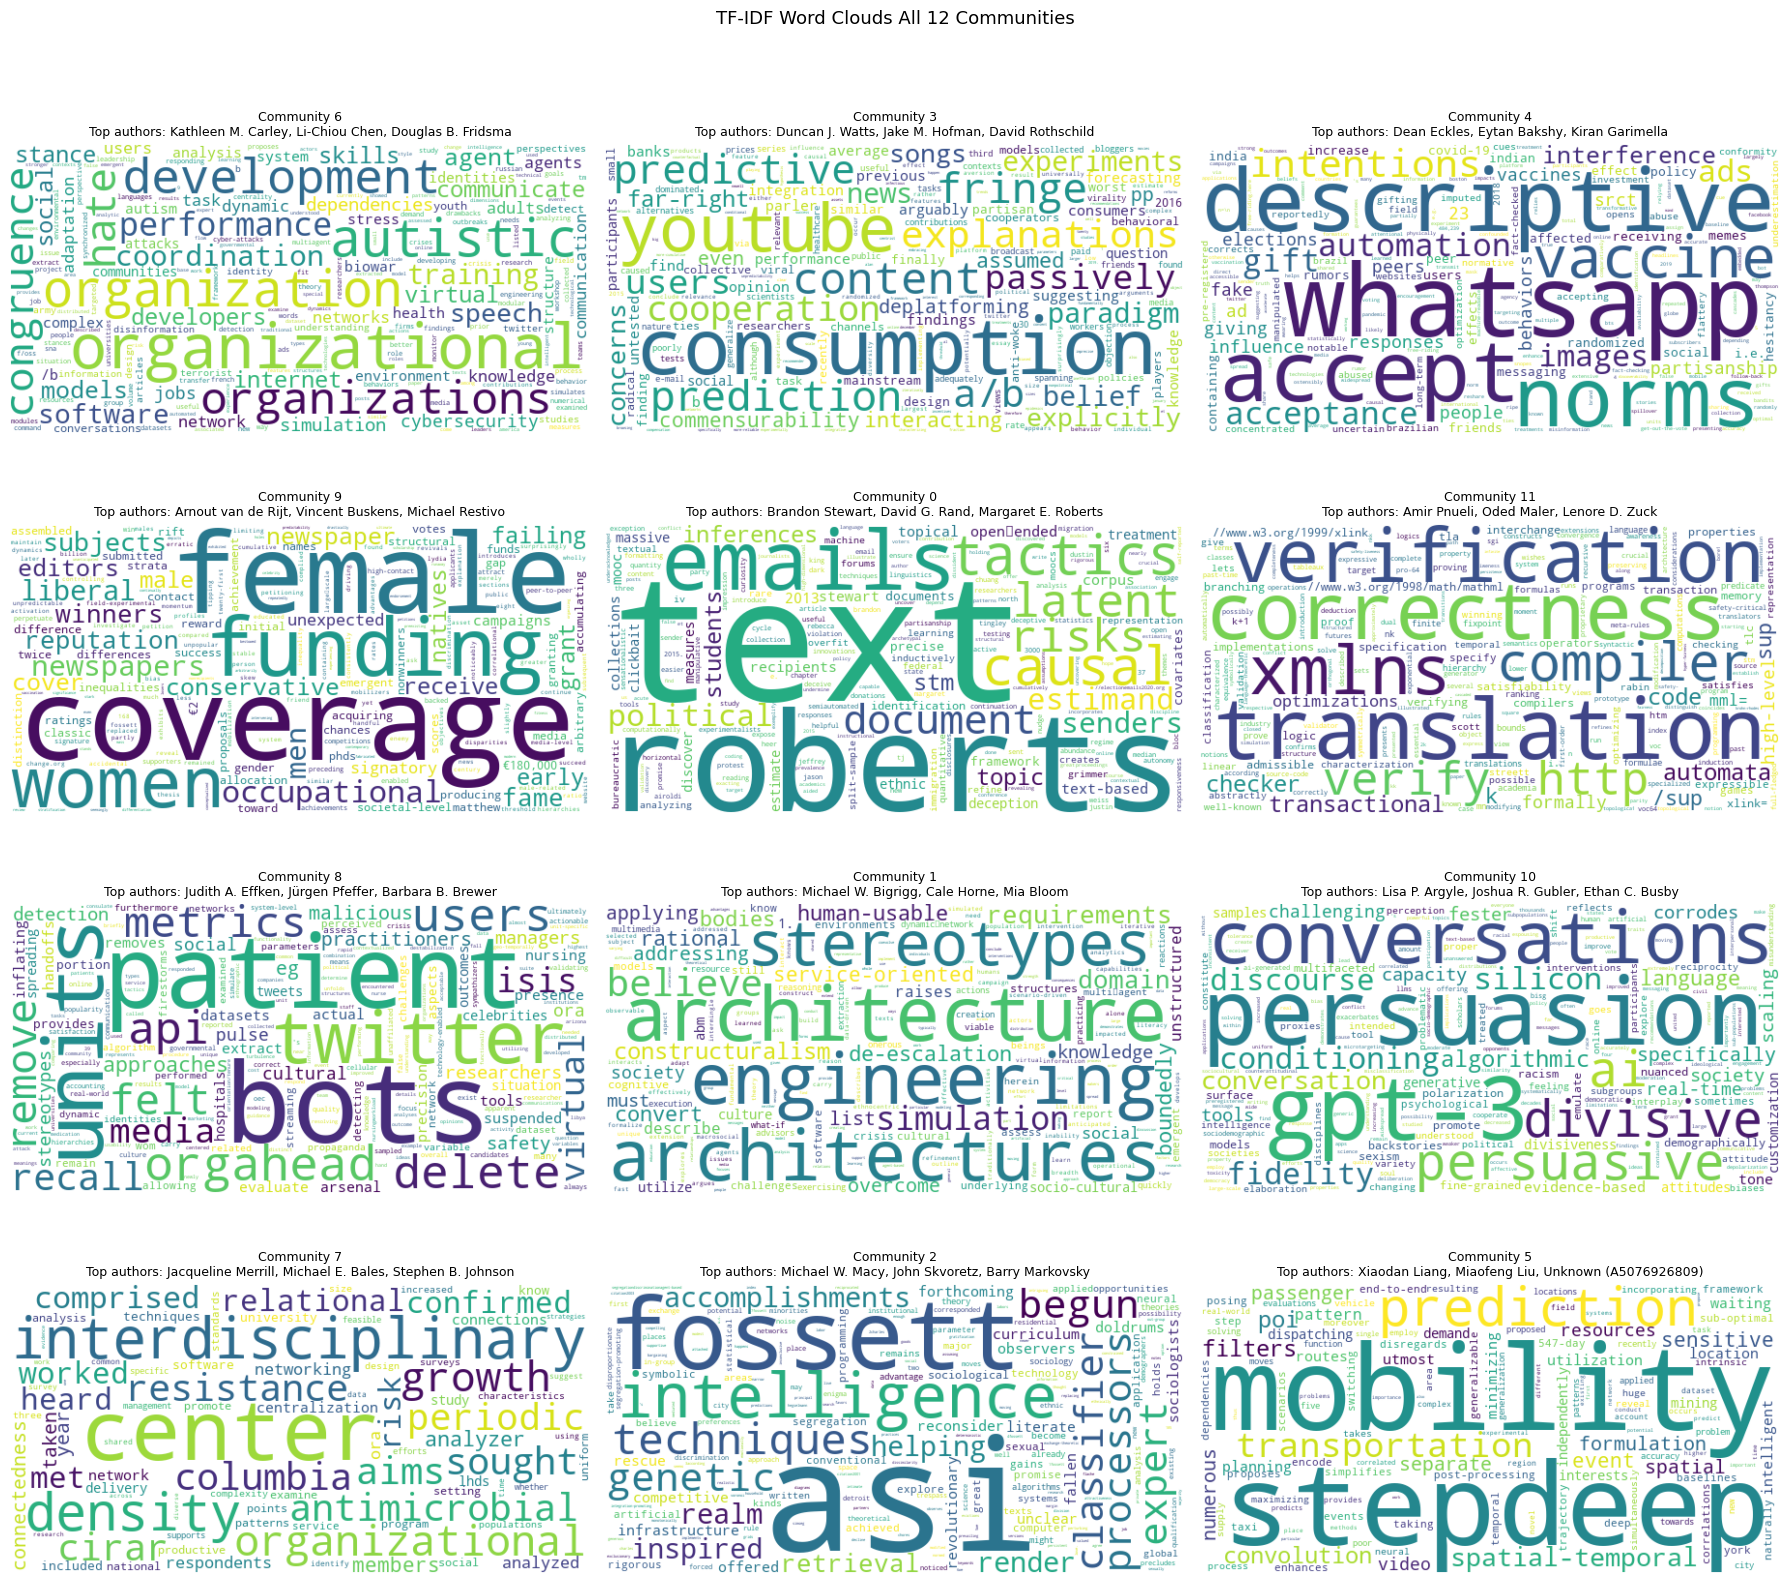

In [123]:
import numpy as np  # needed for atleast_1d

# Order by community size so largest appear first; fit into 3-column grid
communities_by_size = [c for c in community_df['community'].value_counts().index if c != 12]  # exclude community 12 (no abstract data)
n_cols = 3
n_rows = math.ceil(len(communities_by_size) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes_flat = np.atleast_1d(axes).flatten()

for idx, comm in enumerate(communities_by_size):
    ax = axes_flat[idx]

    # Use TF-IDF weights fall back to raw TF if TF-IDF is empty
    frequencies = tf_idf_community.get(comm, {}) or tf_community.get(comm, {})

    # Resolve top-3 authors using combined_name_map (CSV1 + CSV2 + manual)
    top3 = (
        community_df[community_df['community'] == comm].sort_values(by=['degree', 'author_id'], ascending=[False, True]).head(3)
    )
    author_names = [author_label(aid) for aid in top3['author_id']]

    if frequencies:
        wc = WordCloud(width=600, height=300, background_color='white', colormap='viridis')
        ax.imshow(wc.generate_from_frequencies(frequencies), interpolation='bilinear')
    else:
        # No tokens available — show placeholder
        ax.set_facecolor('#f4f4f4')
        ax.text(0.5, 0.56, 'No word cloud available',
                ha='center', va='center', fontsize=12, fontweight='bold', transform=ax.transAxes)
        ax.text(0.5, 0.44, 'No abstract text in dataset.',
                ha='center', va='center', fontsize=10, transform=ax.transAxes)

    ax.axis('off')
    ax.set_title(f"Community {comm}\nTop authors: {', '.join(author_names)}", fontsize=9, pad=6)

for ax in axes_flat[len(communities_by_size):]:
    ax.axis('off')

plt.suptitle(f'TF-IDF Word Clouds All {len(communities_by_size)} Communities', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


Note: Community 12 is not included in the word-cloud figure because its papers do not contain usable abstract text in the dataset. Since a word cloud requires tokenized text, there are no terms available to visualize for that community.

### *What do the word cloud sub-communities reveal about Computational Social Science?*

The word clouds confirm that Computational Social Science is not a single unified discipline but a diverse collection of sub-fields held together by shared methods.

Looking at the substantive communities: Community 9 (*female*, *coverage*, *newspapers*) focuses on gender and media research. Community 4 (*whatsapp*, *norms*, *acceptance*) studies behavioural interventions on digital platforms. Community 6 (*organizational*, *coordination*, *training*) centres on computational organisation science. Community 0 (*stm*, *estimand*, *causal*, *latent*) is primarily methodological, researchers unified by text-as-data and causal inference tools rather than a shared topic.

Community 11 (*xmlns*, *verify*, *temporal*, *correctness*, *branching*) seems to be different from the others as it seems more computational and technical, with a focus on formal code and verification. 

Overall, the field appears to be held together more by shared computational methods (network analysis, text mining, large-scale data collection, causal inference) than by any single research topic. Although by design the TF-IDF helps differentiate the different communities.

### Top Author per Community: Research Field Lookup

For each community, we looked up the top-degree author and checked whether their research area matches the TF-IDF words. Names were resolved from `final_authors.csv`, `final_authors2.csv`, and a manual `Missing_names` dict. 

| Community | Top Author | Research Focus | Matches TF-IDF Terms? |
|-----------|-----------|----------------|-----------------------|
| 6 | Kathleen M. Carley | Computational organisation science | Yes: *organizational*, *software*, *virtual* fit her work on organisational modelling and simulation |
| 3 | Duncan J. Watts | Network science, social influence | Yes: *cooperation*, *prediction*, *explanations* connect to his work on social influence and diffusion, *youtube* and *far-right* could be topic specific on influences |
| 4 | Dean Eckles | Causal inference, digital platforms | Partly: main terms like *Contagion* could be missing. Strong on digital platforms, *whatsapp* and *memes*|
| 9 | Arnout van de Rijt | Social stratification, inequality | Yes: *female*, *women*, *occupational* match his work on inequality and gender gaps |
| 0 | Brandon Stewart | Text-as-data, structural topic models | Strong match: *stm*, *roberts*, *estimand* directly reference his STM software and methods papers |
| 11 | Amir Pnueli | Formal verification, temporal logic | Yes: *verify*, *correctness* sound like verification as well as words being "logical". |
| 8 | Barbara B. Brewer | Public administration, nursing informatics | Partly: *patient*, *safety*, *metrics* overlap with public-sector work, but *api* and *delete* suggest mixed content |
| 1 | Michael W. Bigrigg | Engineering education | Yes: *architecture*, *engineering*, *simulation* match |
| 10 | Lisa P. Argyle | Political science, AI and society | Yes: *persuasion*, *gpt-3*, *divisive*, *ai* align with her work on AI-generated political text |
| 2 | Michael W. Macy | Computational social science, polarisation | Yes: *intelligence* and *techniques* fit his work on computational models of social dynamics |
| 7 | Jacqueline Merrill | Public health informatics, network analysis | Yes: *interdisciplinary*, *organizational*, *density* align with her work on health network analysis |
| 5 | Xiaodan Liang | Machine learning, computer vision | Yes: *mobility*, *transportation*, *spatial-temporal* match urban mobility and deep learning research |


The search does fit quite well with the top authors' research areas. 

## Exercise 3

#### *Has your understanding of Computational Social Science changed after doing this analysis? How?*

Yes. Before this analysis and course we knew almost nothing about Computational Social Science. Looking at the word clouds it seems like Computational Social Science can be a variety of topics, ranging from different subfields of social science to more methodological work. The field is not just about applying computational tools to traditional social science questions, but also about developing new methods and working on a wide range of substantive topics.